In [1]:
import pandas
import matplotlib.pyplot as plt
from pyomo.environ import *
from IPython.display import display # this one can be used to display dataframes in case you want to print out multiple of them

# Problem 1 (small scale, one configuration)
urlParameters = 'https://raw.githubusercontent.com/acedesci/scanalytics/master/EN/S11_Disruption_Management/inputParameters_Prob1.csv'
urlScenario  = 'https://raw.githubusercontent.com/acedesci/scanalytics/master/EN/S11_Disruption_Management/inputScenarios_Prob1.csv'

# Problem 2 (large scale, 3 possible SC configurations - A, B and C)
# urlParameters = 'https://raw.githubusercontent.com/acedesci/scanalytics/master/EN/S11_Disruption_Management/inputParameters_Prob2.csv'

# Here are the scenarios under each configuration. The analysis could be done for one SC configuration at a time so only choose one url among them.
# urlScenario  = 'https://raw.githubusercontent.com/acedesci/scanalytics/master/EN/S11_Disruption_Management/inputScenarios_Prob2_Config_A.csv'
# urlScenario  = 'https://raw.githubusercontent.com/acedesci/scanalytics/master/EN/S11_Disruption_Management/inputScenarios_Prob2_Config_B.csv'
# urlScenario  = 'https://raw.githubusercontent.com/acedesci/scanalytics/master/EN/S11_Disruption_Management/inputScenarios_Prob2_Config_C.csv'

# read CSV files
inputScenarios = pandas.read_csv(urlScenario)
inputParameters = pandas.read_csv(urlParameters)

# Just in case you want to see the loaded DataFrames, you can display or print them
# (display gives a more beautiful output for DataFrame)
display(inputScenarios)
display(inputParameters)

,Node,Product,Scenario_0,Scenario_1,Scenario_2,Scenario_3
0,S1,P1,1,0,1,1
1,S1,P2,1,0,1,1
2,S2,P1,1,1,0,1
3,S2,P2,1,1,0,1
4,S3,P1,1,1,1,0
5,S3,P2,1,1,1,0


,Type,Parameter,Index,Value
0,Supplier,Capacity,S1,30
1,Supplier,Capacity,S2,45
2,Supplier,Capacity,S3,60
3,Product,Demand,P1,75
4,Product,Demand,P2,50
5,Product,Inventory,P1,20
6,Product,Inventory,P2,25
7,Product,Loss,P1,5000
8,Product,Loss,P2,6500
9,Disruption,TTR,Scenario_0,2


In [2]:
productList = inputParameters.loc[inputParameters['Type']=='Product']['Index'].unique()
supplierList = inputParameters.loc[inputParameters['Type']=='Supplier']['Index'].unique()
scenarioList = inputParameters.loc[inputParameters['Type']=='Disruption']['Index'].unique()

supplierCapacityDict = {}
for i in supplierList:
  cap = inputParameters.loc[(inputParameters['Parameter']=='Capacity') & (inputParameters['Index']==i)]['Value'].values[0]
  supplierCapacityDict[i] = cap

print('Print SupplierCapacityDict')
for key in supplierCapacityDict:
    print(key, ' : ', supplierCapacityDict[key])
#print('\n')

productDemandDict = {}
productInvDict = {}
productLossDict = {}

for j in productList:
  dem = inputParameters.loc[(inputParameters['Parameter']=='Demand') & (inputParameters['Index']==j)]['Value'].values[0]
  inv = inputParameters.loc[(inputParameters['Parameter']=='Inventory') & (inputParameters['Index']==j)]['Value'].values[0]
  loss = inputParameters.loc[(inputParameters['Parameter']=='Loss') & (inputParameters['Index']==j)]['Value'].values[0]
  productDemandDict[j] = dem
  productInvDict[j] = inv
  productLossDict[j] = loss

print('Print productDemandDict')
for key in productDemandDict:
    print(key, ' : ', productDemandDict[key])
#print('\n')

print('Print productInvDict')
for key in productInvDict:
    print(key, ' : ', productInvDict[key])
#print('\n')

print('Print productLossDict')
for key in productLossDict:
    print(key, ' : ', productLossDict[key])
#print('\n')

scenarioTTRDict = {}
scenarioActiveNodeDict = {}
for n in scenarioList:
  ttr = inputParameters.loc[(inputParameters['Parameter']=='TTR') & (inputParameters['Index']==n)]['Value'].values[0]
  scenarioTTRDict[n] = ttr
  scenarioActiveNodeDict[n] = {}
  nActiveLinks = sum(inputScenarios[n].values)
  print(str(n)+": N. active links = ", nActiveLinks)

  for ind in range(len(inputScenarios.index)):
    supp = inputScenarios.iloc[ind]['Node']
    prod = inputScenarios.iloc[ind]['Product']
    scenarioActiveNodeDict[n][(supp,prod)] = inputScenarios[n].values[ind]

Print SupplierCapacityDict
S1  :  30
S2  :  45
S3  :  60
Print productDemandDict
P1  :  75
P2  :  50
Print productInvDict
P1  :  20
P2  :  25
Print productLossDict
P1  :  5000
P2  :  6500
Scenario_0: N. active links =  6
Scenario_1: N. active links =  4
Scenario_2: N. active links =  4
Scenario_3: N. active links =  4


In [3]:
# TTR Model

disruptionCost = {}
disruptionResponse = {}
disruptionDemandLoss = {}

resultcolumns = ['disruptionCost', 'riskExposureIndex', 'lostUnits', 'totalProduction', 'activeLinks','utilizedLinks']
TTRscenarioResults = pandas.DataFrame(columns = resultcolumns, index = scenarioList)

for n in scenarioList:
  # print("Analyzing:"+str(n))
  model = ConcreteModel()

  # Variables
  model.l = Var(productList, within = NonNegativeReals)
  model.y = Var(supplierList, productList, within = NonNegativeReals)

  model.demandLoss = ConstraintList()
  model.supplierCapacity = ConstraintList()

  # Objective function
  obj_expr = sum(productLossDict[j]*model.l[j] for j in productList)
  # print(obj_expr)
  model.OBJ = Objective(expr = obj_expr, sense = minimize)

  # Constraints 1 calculate demand loss for each product
  for j in productList:
    const_expr = sum(scenarioActiveNodeDict[n][(i,j)]*model.y[(i,j)] for i in supplierList) + \
                  model.l[j] >= productDemandDict[j]*scenarioTTRDict[n] - productInvDict[j]
    # print(const_expr)
    model.demandLoss.add(expr = const_expr)

  # Constraints 2 capacity at each supplier i
  for i in supplierList:
    # check if there is any left hand side (i.e., if there is at least one available active link), otherwise pyomo will return an error
    noSupply = True
    for j in productList:
      if scenarioActiveNodeDict[n][(i,j)] > 0:
        noSupply = False
        break

    # we generate the constraint only if noSupply = False
    if not noSupply:
      const_expr = sum(scenarioActiveNodeDict[n][(i,j)]*model.y[(i,j)] for j in productList) <= supplierCapacityDict[i]*scenarioTTRDict[n]
      #print(const_expr)
      model.supplierCapacity.add(expr = const_expr)

  # Solve the model
  opt = SolverFactory('glpk')
  opt.solve(model)

  # Save the result for each scenario

  disruptionCost[n] = model.OBJ()
  TTRscenarioResults.loc[n, 'disruptionCost'] = disruptionCost[n]

  disruptionResponse[n] = {}
  nUtilizedLinks = 0
  for ind in range(len(inputScenarios.index)):
      i = inputScenarios.iloc[ind]['Node']
      j = inputScenarios.iloc[ind]['Product']

      if model.y[(i,j)].value is not None:
        disruptionResponse[n][(i,j)] = model.y[(i,j)].value
        if model.y[(i,j)].value > 0.1:
          nUtilizedLinks += 1
      else:
        disruptionResponse[n][(i,j)] = 0

  TTRscenarioResults.loc[n, 'totalProduction'] = sum(disruptionResponse[n].values())
  TTRscenarioResults.loc[n, 'activeLinks'] = sum(scenarioActiveNodeDict[n].values())
  TTRscenarioResults.loc[n, 'utilizedLinks'] = nUtilizedLinks

  disruptionDemandLoss[n] = {}
  for j in productList:
    disruptionDemandLoss[n][j] = model.l[j].value

  TTRscenarioResults.loc[n, 'lostUnits'] = sum(disruptionDemandLoss[n].values())

if TTRscenarioResults['disruptionCost'].max() > 0.001:
  TTRscenarioResults['riskExposureIndex'] = TTRscenarioResults['disruptionCost']/TTRscenarioResults['disruptionCost'].max()
else: TTRscenarioResults['riskExposureIndex'] = 0.0

# Show the results
pandas.options.display.float_format = '{:,.3f}'.format
display(TTRscenarioResults)

,disruptionCost,riskExposureIndex,lostUnits,totalProduction,activeLinks,utilizedLinks
Scenario_0,0.000,0.000,0.000,205.000,6,4
Scenario_1,0.000,0.000,0.000,205.000,4,3
Scenario_2,"125,000.000",0.455,25.000,180.000,4,3
Scenario_3,"275,000.000",1.000,55.000,150.000,4,3


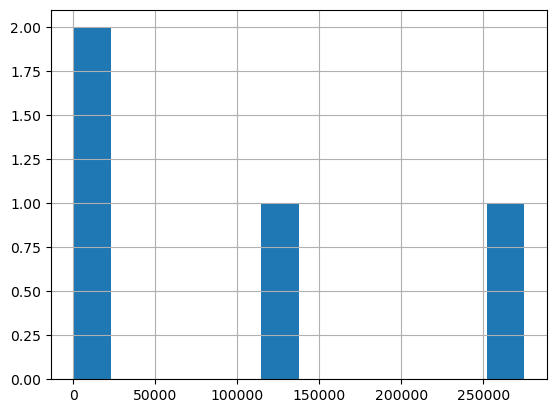

In [4]:
# Here we make use of the function hist() to plot the histogram based on the analyzed scenarios
TTRscenarioResults['disruptionCost'].astype(int).hist(bins=12)
plt.show()

In [5]:
# TTS Model

timeToSurvive = {}
disruptionResponse = {}
disruptionDemandLoss = {}

resultcolumns = ['TTS', 'TTR', 'nShortagePeriods', 'activeLinks','utilizedLinks']
TTSscenarioResults = pandas.DataFrame(columns = resultcolumns, index = scenarioList)

for n in scenarioList:
  # print("Analyzing:"+str(n))
  model = ConcreteModel()

  # Variables
  # There is only one variable t so we give a list of one value.
  # If the SC is robust for that scenario, the variable t will be equal to infinity
  # so we limit the max to a sufficiently large number (999 periods in this case)
  model.t = Var([0], within = NonNegativeReals, bounds=(0,999))
  model.y = Var(supplierList, productList, within = NonNegativeReals)

  model.demandSatisfaction = ConstraintList()
  model.supplierCapacity = ConstraintList()

  # Objective function
  obj_expr =model.t[0]
  # print(obj_expr)
  model.OBJ = Objective(expr = obj_expr, sense = maximize)

  # Constraints 1 demand must be fully satisfied
  for j in productList:
    const_expr = sum(scenarioActiveNodeDict[n][(i,j)]*model.y[(i,j)] for i in supplierList) \
                  >= productDemandDict[j]*model.t[0] - productInvDict[j]
    # print(const_expr)
    model.demandSatisfaction.add(expr = const_expr)

  # Constraints 2 capacity at each supplier i
  for i in supplierList:
    # check if there is any left hand side (i.e., if there is at least one available active link), otherwise pyomo will return an error
    noSupply = True
    for j in productList:
      if scenarioActiveNodeDict[n][(i,j)] > 0:
        noSupply = False
        break

    # we generate the constraint only if noSupply = False
    if not noSupply:
      const_expr = sum(scenarioActiveNodeDict[n][(i,j)]*model.y[(i,j)] for j in productList) <= supplierCapacityDict[i]*model.t[0]
      #print(const_expr)
      model.supplierCapacity.add(expr = const_expr)

  # Solve the model
  opt = SolverFactory('glpk')
  opt.solve(model)

  # Save the result for each scenario

  timeToSurvive[n] = model.OBJ()
  TTSscenarioResults.loc[n, 'TTS'] = round(timeToSurvive[n],3)
  TTSscenarioResults.loc[n, 'TTR'] = scenarioTTRDict[n]

  disruptionResponse[n] = {}
  nUtilizedLinks = 0
  for ind in range(len(inputScenarios.index)):
      i = inputScenarios.iloc[ind]['Node']
      j = inputScenarios.iloc[ind]['Product']

      if model.y[(i,j)].value is not None:
        disruptionResponse[n][(i,j)] = model.y[(i,j)].value
        if model.y[(i,j)].value > 0.1:
          nUtilizedLinks += 1
      else:
        disruptionResponse[n][(i,j)] = 0

  TTSscenarioResults.loc[n, 'nShortagePeriods'] = max(TTSscenarioResults.loc[n, 'TTR'] - TTSscenarioResults.loc[n, 'TTS'], 0)
  TTSscenarioResults.loc[n, 'activeLinks'] = sum(scenarioActiveNodeDict[n].values())
  TTSscenarioResults.loc[n, 'utilizedLinks'] = nUtilizedLinks

# Show the results
pandas.options.display.float_format = '{:,.3f}'.format
display(TTSscenarioResults)

,TTS,TTR,nShortagePeriods,activeLinks,utilizedLinks
Scenario_0,999.000,2,0,6,4
Scenario_1,2.250,2,0,4,3
Scenario_2,1.286,2,0.714,4,3
Scenario_3,0.900,2,1.100,4,3


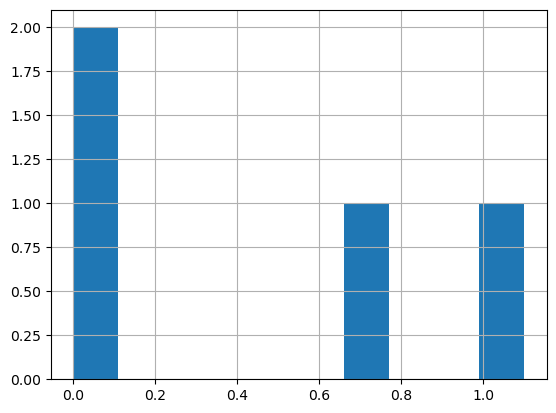

,TTS,TTR,nShortagePeriods,activeLinks,utilizedLinks
Scenario_0,999.000,2,0,6,4
Scenario_1,2.250,2,0,4,3
Scenario_2,1.286,2,0.714,4,3
Scenario_3,0.900,2,1.100,4,3


In [6]:
# Intepret and show the results
# Here we make use of the function hist() to plot the histogram
TTSscenarioResults['nShortagePeriods'].hist()
plt.show()

display(TTSscenarioResults)